In [1]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [2]:
s1_interferogram = connection.datacube_from_process(
    "sentinel1_sar_interferogram",
    namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/refs/heads/main/algorithm_catalog/eurac/sentinel1_sar_interferogram/openeo_udp/sentinel1_sar_interferogram.json",
    polarization="VV",
    sub_swath="IW1",
    spatial_extent={
        "west": 13.10,
        "south": 42.60,
        "east": 13.38,
        "north": 42.78
    },
    temporal_baseline=6,
    temporal_extent = ["2016-08-18", "2016-11-18"]
)

In [3]:
cube = s1_interferogram.create_job(title="SAR interferogram VV only")
job = cube.start_and_wait()

0:00:00 Job 'j-2608241206124d159bc91e3d991931ea': send 'start'
0:00:03 Job 'j-2608241206124d159bc91e3d991931ea': created (progress 0%)
0:00:08 Job 'j-2608241206124d159bc91e3d991931ea': queued (progress 0%)
0:00:15 Job 'j-2608241206124d159bc91e3d991931ea': queued (progress 0%)
0:00:23 Job 'j-2608241206124d159bc91e3d991931ea': queued (progress 0%)
0:00:33 Job 'j-2608241206124d159bc91e3d991931ea': queued (progress 0%)
0:00:45 Job 'j-2608241206124d159bc91e3d991931ea': queued (progress 0%)
0:01:01 Job 'j-2608241206124d159bc91e3d991931ea': queued (progress 0%)
0:01:20 Job 'j-2608241206124d159bc91e3d991931ea': running (progress N/A)
0:01:44 Job 'j-2608241206124d159bc91e3d991931ea': running (progress N/A)
0:02:14 Job 'j-2608241206124d159bc91e3d991931ea': running (progress N/A)
0:02:51 Job 'j-2608241206124d159bc91e3d991931ea': running (progress N/A)
0:03:38 Job 'j-2608241206124d159bc91e3d991931ea': running (progress N/A)
0:04:36 Job 'j-2608241206124d159bc91e3d991931ea': running (progress N/A)
0

<BatchJob job_id='j-2608241206124d159bc91e3d991931ea'>

In [5]:
result = job.get_results()
result.download_files("sar_interferogram/")

[WindowsPath('sar_interferogram/phase_coh_20160822T165740_20160828T165658.tif'),
 WindowsPath('sar_interferogram/phase_coh_20160828T165658_20160903T165740.tif'),
 WindowsPath('sar_interferogram/phase_coh_20160927T165741_20161003T165659.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161003T165659_20161009T165741.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161009T165741_20161015T165659.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161015T165659_20161021T165741.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161021T165741_20161027T165659.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161027T165659_20161102T165741.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161102T165741_20161108T165659.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161108T165659_20161114T165741.tif'),
 WindowsPath('sar_interferogram/job-results.json')]

In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import xarray as xr

import glob
import re
from datetime import datetime

bands: 3 | descriptions: ('Phase_ifg_VV', 'Unw_Phase_ifg_VV', 'coh_VV') | crs: EPSG:4326


C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_29592\825535503.py:4: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  wrapped_phase = src.read(1)
C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_29592\825535503.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  unwrapped_phase = src.read(2)
C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_29592\825535503.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  coherence = src.read(3)


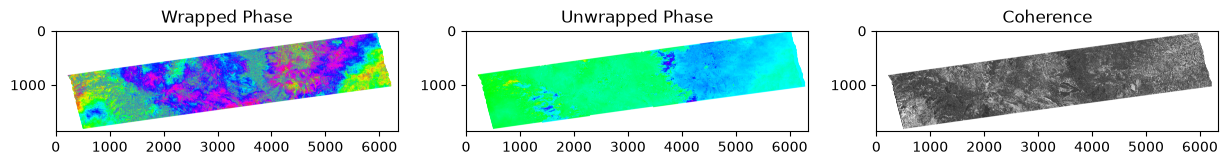

In [2]:
quicklook_path = "sar_interferogram/phase_coh_20161108T165659_20161114T165741.tif"
with rasterio.open(quicklook_path) as src:
    print("bands:", src.count, "| descriptions:", src.descriptions, "| crs:", src.crs)
    wrapped_phase = src.read(1)
    unwrapped_phase = src.read(2)
    coherence = src.read(3)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(wrapped_phase, cmap='hsv')
axs[0].set_title("Wrapped Phase")
axs[1].imshow(unwrapped_phase, cmap='hsv')
axs[1].set_title("Unwrapped Phase")
axs[2].imshow(coherence, cmap='gray')
axs[2].set_title("Coherence")
plt.show()

In [3]:
INTERFEROGRAM_DIR = "sar_interferogram/"
pair_filename_pattern = re.compile(r"phase_coh_(\d{8}T\d{6})_(\d{8}T\d{6})\.tif$")

In [4]:
# list all interferogram pairs and sort them by start time
pairs = []
for path in glob.glob(f"{INTERFEROGRAM_DIR}/phase_coh_*.tif"):
    match = pair_filename_pattern.search(path)
    start_time = datetime.strptime(match.group(1), "%Y%m%dT%H%M%S")
    end_time = datetime.strptime(match.group(2), "%Y%m%dT%H%M%S")
    pairs.append((start_time, end_time, path))

pairs.sort(key=lambda x: x[0])  # Sort by start time
print(f"Found {len(pairs)} interferogram pairs")

Start Time: 2016-11-08 16:56:59, End Time: 2016-11-14 16:57:41, length: 10


In [5]:
displacement_results = []
for start_time, end_time, path in pairs:
    print(f"Processing interferogram from {start_time} to {end_time} at {path}")
    # create a dataset for each interferogram
    with rasterio.open(path) as src:
        wrapped_phase = src.read(1)
        unwrapped_phase = src.read(2)
        coherence = src.read(3)
        # store metadata for later alignment
        transform = src.transform
        crs = src.crs
        bounds = src.bounds
        
        # Create basic dataset
        ds = xr.Dataset(
            {
                "wrapped_phase": (("y", "x"), wrapped_phase),
                "unwrapped_phase": (("y", "x"), unwrapped_phase),
                "coherence": (("y", "x"), coherence),
            },
            coords={
                "y": np.arange(src.height),
                "x": np.arange(src.width),
            }
        )
        
        displacement_results.append({
            "start": start_time,
            "end": end_time,
            "path": path,
            "dataset": ds,
            "transform": transform,
            "crs": crs,
            "bounds": bounds
        })

print(f"Loaded {len(displacement_results)} interferogram pairs")

Processing interferogram from 2016-08-22 16:57:40 to 2016-08-28 16:56:58 at sar_interferogram\phase_coh_20160822T165740_20160828T165658.tif


C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_29592\2097116121.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  wrapped_phase = src.read(1)
C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_29592\2097116121.py:7: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  unwrapped_phase = src.read(2)
C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_29592\2097116121.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  coherence = src.read(3)


Processing interferogram from 2016-08-28 16:56:58 to 2016-09-03 16:57:40 at sar_interferogram\phase_coh_20160828T165658_20160903T165740.tif
Processing interferogram from 2016-09-27 16:57:41 to 2016-10-03 16:56:59 at sar_interferogram\phase_coh_20160927T165741_20161003T165659.tif
Processing interferogram from 2016-10-03 16:56:59 to 2016-10-09 16:57:41 at sar_interferogram\phase_coh_20161003T165659_20161009T165741.tif
Processing interferogram from 2016-10-09 16:57:41 to 2016-10-15 16:56:59 at sar_interferogram\phase_coh_20161009T165741_20161015T165659.tif
Processing interferogram from 2016-10-15 16:56:59 to 2016-10-21 16:57:41 at sar_interferogram\phase_coh_20161015T165659_20161021T165741.tif
Processing interferogram from 2016-10-21 16:57:41 to 2016-10-27 16:56:59 at sar_interferogram\phase_coh_20161021T165741_20161027T165659.tif
Processing interferogram from 2016-10-27 16:56:59 to 2016-11-02 16:57:41 at sar_interferogram\phase_coh_20161027T165659_20161102T165741.tif
Processing interfero

## Step 1: Convert unwrapped phase to line-of-sight displacement

The unwrapped phase (in radians) is converted to displacement using:
- **d = -(λ/4π) × Δφ**
- λ (wavelength) for Sentinel-1 VV = 0.0554 m
- Negative values = motion away from satellite (subsidence)
- Positive values = motion toward satellite (uplift)

In [6]:
# Sentinel-1 wavelength (VV band, C-band)
WAVELENGTH = 0.0554  # meters

# Threshold for coherence - pixels below this are masked out as low-quality
COHERENCE_THRESHOLD = 0.30

# Process each interferogram pair
for result in displacement_results:
    ds = result["dataset"]
    
    # Step 1: Convert unwrapped phase (radians) to line-of-sight displacement (meters)
    # Formula: d = -(λ/4π) × Δφ
    los_displacement = -(WAVELENGTH / (4 * np.pi)) * ds["unwrapped_phase"]
    
    # Step 2: Apply coherence masking
    # Low coherence means low correlation, unreliable measurement
    coherence_mask = ds["coherence"] < COHERENCE_THRESHOLD
    los_displacement_masked = los_displacement.where(~coherence_mask, np.nan)
    
    # Step 3: Apply gradient masking (mask steep phase gradients = unwrapping artifacts)
    # Compute phase gradient in x and y directions
    phase_grad_x = np.abs(np.diff(ds["unwrapped_phase"].values, axis=1, prepend=np.nan))
    phase_grad_y = np.abs(np.diff(ds["unwrapped_phase"].values, axis=0, prepend=np.nan))
    phase_gradient_magnitude = np.sqrt(phase_grad_x**2 + phase_grad_y**2)
    
    # Mask pixels in steepest 2% of gradients (likely unwrapping artifacts)
    gradient_threshold = np.nanpercentile(phase_gradient_magnitude, 98)
    gradient_mask = phase_gradient_magnitude > gradient_threshold
    los_displacement_masked = los_displacement_masked.where(~gradient_mask, np.nan)
    
    # Store result in displacement_results
    result["los_displacement"] = los_displacement_masked
    
    # Report statistics
    valid_pixels = np.sum(~np.isnan(los_displacement_masked.values))
    total_pixels = los_displacement_masked.size
    valid_fraction = valid_pixels / total_pixels if total_pixels > 0 else 0
    print(f"{result['start'].date()} → {result['end'].date()}: {valid_fraction:.1%} pixels valid "
          f"(after coherence & gradient masking)")

2016-08-22 → 2016-08-28: 32.4% pixels valid (after coherence & gradient masking)
2016-08-28 → 2016-09-03: 33.0% pixels valid (after coherence & gradient masking)
2016-09-27 → 2016-10-03: 32.5% pixels valid (after coherence & gradient masking)
2016-10-03 → 2016-10-09: 31.5% pixels valid (after coherence & gradient masking)
2016-10-09 → 2016-10-15: 33.9% pixels valid (after coherence & gradient masking)
2016-10-15 → 2016-10-21: 34.6% pixels valid (after coherence & gradient masking)
2016-10-21 → 2016-10-27: 34.0% pixels valid (after coherence & gradient masking)
2016-10-27 → 2016-11-02: 34.2% pixels valid (after coherence & gradient masking)
2016-11-02 → 2016-11-08: 31.8% pixels valid (after coherence & gradient masking)
2016-11-08 → 2016-11-14: 34.0% pixels valid (after coherence & gradient masking)


## Step 2: Align all interferograms to a common spatial grid

Each SAR acquisition has a slightly different footprint and pixel grid due to orbit geometry.
We need to reproject them all onto a common grid (the intersection of all footprints) so we can stack them.


In [7]:
from rasterio.warp import reproject, Resampling
from rasterio.transform import Affine

# Compute the common grid: intersection of all interferogram footprints
crs = displacement_results[0]["crs"]
bounds_list = [r["bounds"] for r in displacement_results]

# Intersection: take max of mins and min of maxs
west = max(b.left for b in bounds_list)
south = max(b.bottom for b in bounds_list)
east = min(b.right for b in bounds_list)
north = min(b.top for b in bounds_list)

print(f"Common grid extent: {west:.5f}°E, {south:.5f}°N to {east:.5f}°E, {north:.5f}°N")

# Get pixel resolution from first interferogram
transform0 = displacement_results[0]["transform"]
res_x = float(transform0.a)  # pixel width (degrees or meters)
res_y = float(abs(transform0.e))  # pixel height (absolute value)

# Compute common grid shape and geotransform
common_shape = (int((north - south) / res_y), int((east - west) / res_x))
common_transform = Affine(res_x, 0.0, west, 0.0, -res_y, north)

print(f"Common grid shape: {common_shape[0]} rows × {common_shape[1]} cols, resolution: {res_x:.6f}°/pixel")

# Reproject each interferogram to the common grid
aligned_displacements = []
for i, result in enumerate(displacement_results):
    los_disp = result["los_displacement"].values  # numpy array
    
    # Create output array for reprojected data
    dst_data = np.full(common_shape, np.nan, dtype="float64")
    
    # Compute source transform from the dataset coordinates
    transform = result["transform"]
    
    # Reproject using bilinear interpolation
    reproject(
        source=los_disp,
        destination=dst_data,
        src_transform=transform,
        src_crs=crs,
        dst_transform=common_transform,
        dst_crs=crs,
        src_nodata=np.nan,
        dst_nodata=np.nan,
        resampling=Resampling.bilinear,
    )
    
    aligned_displacements.append(dst_data)
    print(f"  Reprojected pair {i+1}/{len(displacement_results)}")

# Check array shapes before stacking - make sure they're all identical
shapes = [arr.shape for arr in aligned_displacements]
if len(set(shapes)) > 1:
    print("WARNING: Arrays have different shapes!")
    for i, shape in enumerate(shapes):
        print(f"  Pair {i+1}: {shape}")
else:
    print(f"✓ All {len(aligned_displacements)} arrays have consistent shape: {shapes[0]}")

print(f"All {len(aligned_displacements)} interferograms aligned to common grid")

Common grid extent: 12.74161°E, 42.39500°N to 13.85606°E, 42.72828°N
Common grid shape: 1854 rows × 6203 cols, resolution: 0.000180°/pixel
  Reprojected pair 1/10
  Reprojected pair 2/10
  Reprojected pair 3/10
  Reprojected pair 4/10
  Reprojected pair 5/10
  Reprojected pair 6/10
  Reprojected pair 7/10
  Reprojected pair 8/10
  Reprojected pair 9/10
  Reprojected pair 10/10
✓ All 10 arrays have consistent shape: (1854, 6203)
All 10 interferograms aligned to common grid


## Step 3: Compute cumulative displacement over time

Stack all aligned interferograms and compute cumulative displacement.
This shows how ground deformation accumulated from Aug 18 through Nov 18, 2016.


In [8]:
# Stack all aligned displacement maps into a (time, y, x) array
displacement_stack = np.stack(aligned_displacements, axis=0)

print(f"Displacement stack shape: {displacement_stack.shape} (time, y, x)")

# A pixel masked out on one pair contributes 0 that step (not NaN) so it doesn't
# erase everything after it, but stays NaN in the final map if it was never valid on any pair
ever_valid = np.any(~np.isnan(displacement_stack), axis=0)
cumulative = np.nancumsum(np.nan_to_num(displacement_stack, nan=0.0), axis=0)
total_displacement = np.where(ever_valid, cumulative[-1], np.nan)

print(f"Total displacement range: {np.nanmin(total_displacement):.3f} to {np.nanmax(total_displacement):.3f} m")
print(f"Valid pixels: {np.sum(ever_valid)} out of {ever_valid.size} ({100*np.sum(ever_valid)/ever_valid.size:.1f}%)")

Displacement stack shape: (10, 1854, 6203) (time, y, x)
Total displacement range: -0.341 to 0.339 m
Valid pixels: 6352342 out of 11500362 (55.2%)


## Step 4: Visualize cumulative displacement map

Plot the total line-of-sight displacement accumulated over the entire period.
- **Red** = motion toward satellite (positive displacement)
- **Blue** = motion away from satellite (negative displacement)
- **White/blank** = pixels masked out due to low coherence or phase unwrapping issues


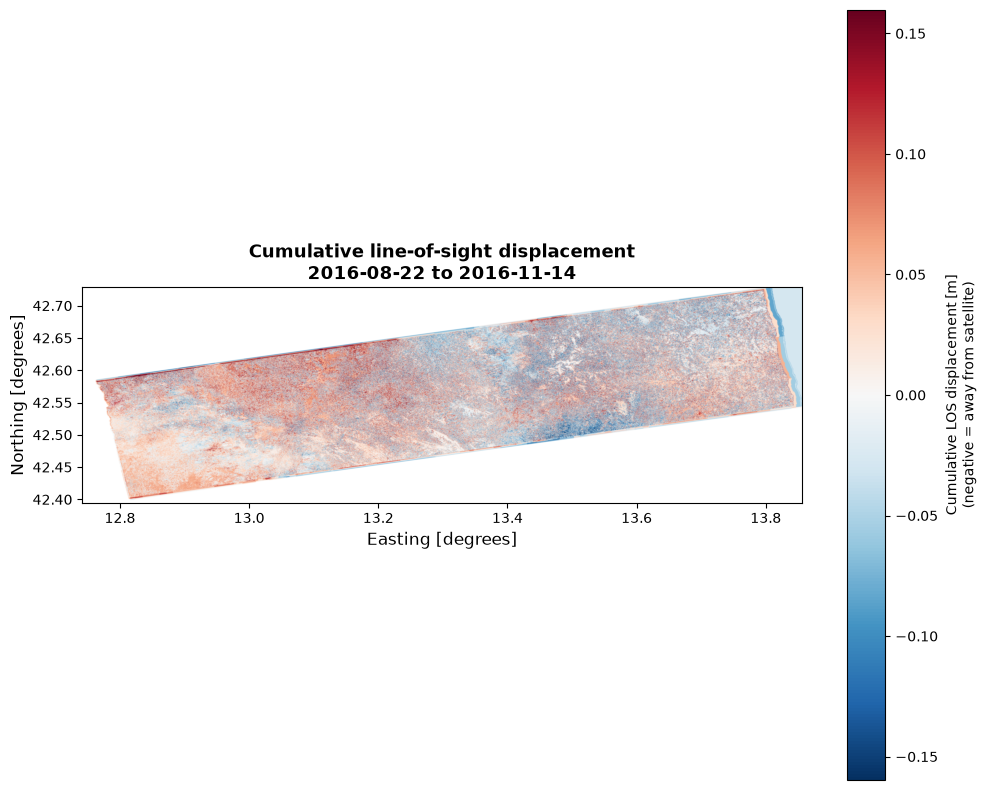

Map extent: 12.7416° to 13.8561°E, 42.3950° to 42.7283°N


In [9]:
# Prepare extent and normalization
extent = [west, east, south, north]
unit = "degrees" if crs.is_geographic else "m"

# Symmetric color scale: use 98th percentile to avoid extreme outliers
vlim = np.nanpercentile(np.abs(total_displacement), 98)

# Create the map
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(total_displacement, cmap="RdBu_r", vmin=-vlim, vmax=vlim, 
               extent=extent, origin="upper", interpolation="bilinear")

ax.set_xlabel(f"Easting [{unit}]", fontsize=12)
ax.set_ylabel(f"Northing [{unit}]", fontsize=12)
ax.set_title("Cumulative line-of-sight displacement\n" + 
             f"{displacement_results[0]['start'].date()} to {displacement_results[-1]['end'].date()}",
             fontsize=13, fontweight="bold")

cbar = fig.colorbar(im, ax=ax, label="Cumulative LOS displacement [m]\n(negative = away from satellite)")
fig.tight_layout()
plt.show()

print(f"Map extent: {west:.4f}° to {east:.4f}°E, {south:.4f}° to {north:.4f}°N")

## Step 5: Time series at the peak deformation pixel

Find the pixel with maximum absolute displacement and show how it deformed over time across all interferogram pairs.
This reveals the temporal evolution of ground motion during the earthquake sequence.


Peak deformation pixel: row 1282, col 4091
Maximum absolute displacement: 0.341 m
Displacement direction: away from satellite


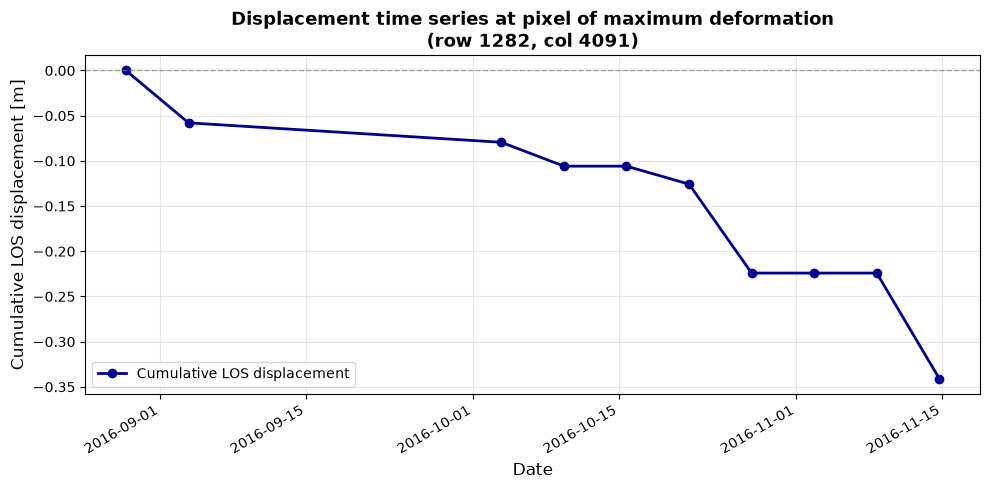

In [10]:
# Find the pixel with maximum deformation
peak_y, peak_x = np.unravel_index(np.nanargmax(np.abs(total_displacement)), total_displacement.shape)

# Get dates for each interferogram pair
dates = [r["end"] for r in displacement_results]

# Extract the time series at the peak pixel across all pairs
pixel_cumulative = cumulative[:, peak_y, peak_x]

print(f"Peak deformation pixel: row {peak_y}, col {peak_x}")
print(f"Maximum absolute displacement: {np.abs(pixel_cumulative[-1]):.3f} m")
print(f"Displacement direction: {'toward satellite' if pixel_cumulative[-1] > 0 else 'away from satellite'}")

# Plot the time series
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dates, pixel_cumulative, marker="o", linewidth=2, markersize=6, color="darkblue", label="Cumulative LOS displacement")
ax.axhline(0, color="grey", linewidth=1, linestyle="--", alpha=0.7)

ax.set_ylabel("Cumulative LOS displacement [m]", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.set_title(f"Displacement time series at pixel of maximum deformation\n(row {peak_y}, col {peak_x})", 
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

fig.autofmt_xdate()  # Rotate date labels
fig.tight_layout()
plt.show()